# Lineaer regresjon -- beregninger i Python

Dette notatet inneholder alle beregningene fra Beamer-forelesningen *Lineaer regresjon*,
basert pa datasettet `Bolig.sav` (n=102 boliger): kurvetilpasning, enkel lineaer regresjon,
minste kvadraters metode, R², dummyvariabler, multippel regresjon, justert R², ANOVA-test,
standardisert beta, multikollinearitet (VIF) og prediksjon.

Alle tall er reproduserbare -- kjor cellene i rekkefolge.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pyreadstat

ORANGE = "#E8743B"
BLUE = "#1f4e8c"
GRAY = "#888888"
RED = "#c0392b"
plt.rcParams["figure.figsize"] = (6.0, 4.0)
plt.rcParams["font.size"] = 11

url = 'https://raw.githubusercontent.com/uit-bed-2501/uit-bed-2501/main/data/Bolig.sav'
df = pd.read_spss(url)

#df, meta = pyreadstat.read_sav("Bolig.sav")
print(df.shape)
df.head()

PyreadstatError: File https://raw.githubusercontent.com/uit-bed-2501/uit-bed-2501/main/data/Bolig.sav does not exist!

**Variabler i Bolig.sav:**

| Variabel | Beskrivelse |
|---|---|
| Pris | Boligpris |
| Areal | Areal malt i kvadratmeter |
| Alder | Alder pa boligen |
| Sentrum | Avstand i kilometer fra sentrum |
| Sol | Gjennomsnittlig antall soltimer per dag |
| Farge | 0 = annen farge enn hvit, 1 = hvit |
| Prisvekst | Prisvekst siste ar |
| Isolasjonsgrad | 1 = under 10 cm, 2 = mellom 10-20 cm, 3 = over 20 cm |

## 1. Kurvetilpasning

Kurvetilpasning (curve fitting) handler om a finne en matematisk funksjon som beskriver
sammenhengen i en punktsky. En *for enkel* modell fanger ikke opp monsteret; en *for
fleksibel* modell tilpasser seg tilfeldig stoy (overtilpasning). Under sammenlignes en
lineaer, en kvadratisk og en sterkt overtilpasset modell pa samme syntetiske datasett.

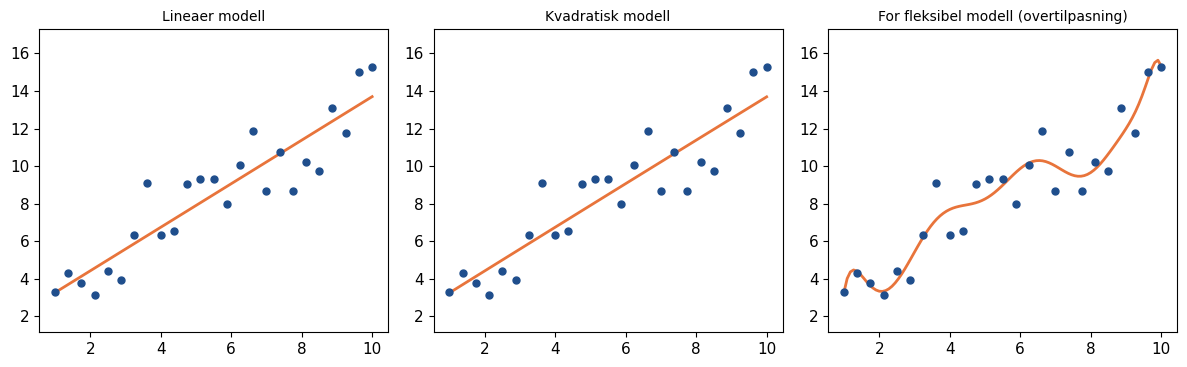

In [2]:
rng = np.random.default_rng(7)
x_cf = np.linspace(1, 10, 25)
y_cf = 2 + 1.3 * x_cf + rng.normal(0, 1.8, 25)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
titles = ["Lineaer modell", "Kvadratisk modell", "For fleksibel modell (overtilpasning)"]
grader = [1, 2, 12]
xs_cf = np.linspace(1, 10, 100)
for ax, title, grad in zip(axes, titles, grader):
    ax.scatter(x_cf, y_cf, color=BLUE, s=25, zorder=3)
    ax.plot(xs_cf, np.polyval(np.polyfit(x_cf, y_cf, grad), xs_cf), color=ORANGE, lw=2)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(y_cf.min() - 2, y_cf.max() + 2)
plt.tight_layout()
plt.show()

I resten av notatet ser vi pa **lineaer** kurvetilpasning -- lineaer regresjon.

## 2. Spredningsdiagram: er det en sammenheng?

Forste steg er a plotte punktene og se om det ser ut som en lineaer sammenheng, for vi
regner ut noe som helst.

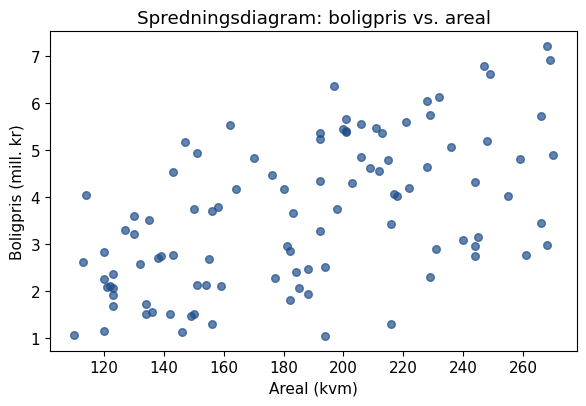

In [3]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.scatter(df["Areal"], df["Pris"] / 1e6, color=BLUE, alpha=0.7, s=30)
ax.set_xlabel("Areal (kvm)")
ax.set_ylabel("Boligpris (mill. kr)")
ax.set_title("Spredningsdiagram: boligpris vs. areal")
plt.tight_layout()
plt.show()

## 3. Avhengig og uavhengig variabel

**Avhengig variabel (y):** `Pris` -- det vi onsker a forklare/predikere.
**Uavhengig variabel(-er) (x):** `Areal`, `Alder`, `Sentrum`, ... -- egenskaper som kan
pavirke prisen.

## 4. Lineaer trend: repetisjon av rett linje

En isselger har fastlonn 600 kr/dag, pluss 3 kr per solgte is: $y=600+3x$
(600 = konstantledd/skjaeringspunkt, 3 = stigningstall).

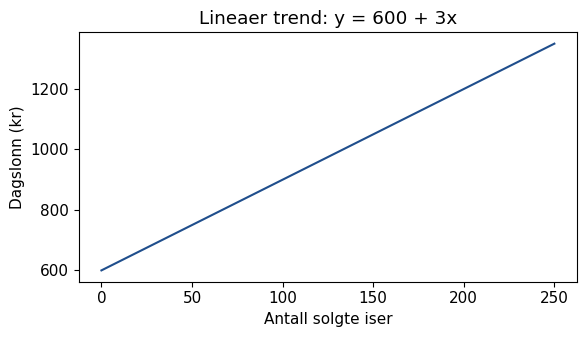

In [4]:
x_line = np.linspace(0, 250, 50)
y_line = 600 + 3 * x_line
plt.figure(figsize=(6, 3.5))
plt.plot(x_line, y_line, color=BLUE)
plt.xlabel("Antall solgte iser")
plt.ylabel("Dagslonn (kr)")
plt.title("Lineaer trend: y = 600 + 3x")
plt.tight_layout()
plt.show()

## 5. Lineaer regresjon og minste kvadraters metode

Vi onsker en linje $\hat y=\hat\alpha+\hat\beta x$ som passer best mulig til datapunktene.
Feilleddet $d_i=y_i-(\hat\alpha+\hat\beta x_i)$ er avstanden mellom observert og modellert
verdi. Vi velger $\hat\alpha,\hat\beta$ som minimerer summen av *kvadrerte* feilledd:

$$D=\sum_{i=1}^n d_i^2=\sum_{i=1}^n\big(y_i-\hat\alpha-\hat\beta x_i\big)^2$$

$$\hat\beta=\frac{S_{xy}}{S_{xx}}=\frac{\sum x_iy_i-n\bar x\bar y}{\sum x_i^2-n\bar x^2},
\qquad \hat\alpha=\bar y-\hat\beta\,\bar x$$

Dette regner vi selv ut for hand for a se metoden, og sjekker mot `scipy.stats.linregress`.

In [5]:
x = df["Areal"].values
y = df["Pris"].values
n = len(x)
xbar, ybar = x.mean(), y.mean()

Sxy = np.sum(x * y) - n * xbar * ybar
Sxx = np.sum(x**2) - n * xbar**2
beta_hat = Sxy / Sxx
alpha_hat = ybar - beta_hat * xbar

print(f"Manuell beregning:  alpha={alpha_hat:.3f}, beta={beta_hat:.3f}")

res = stats.linregress(x, y)
print(f"scipy.stats.linregress: alpha={res.intercept:.3f}, beta={res.slope:.3f}")
print(f"\nR2 = {res.rvalue**2:.4f}, p = {res.pvalue:.2e}")

Manuell beregning:  alpha=121870.277, beta=18791.805
scipy.stats.linregress: alpha=121870.277, beta=18791.805

R2 = 0.3066, p = 1.58e-09


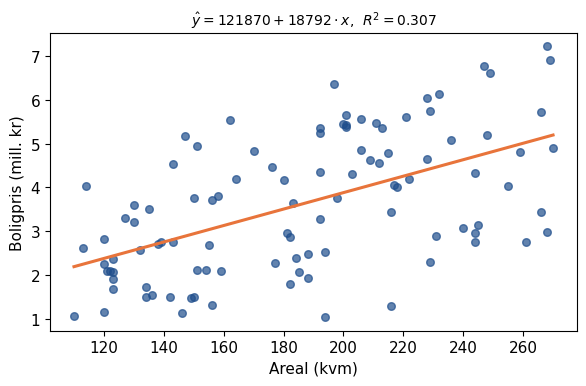

In [6]:
xs = np.linspace(x.min(), x.max(), 50)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y / 1e6, color=BLUE, alpha=0.7, s=30, zorder=3)
ax.plot(xs, (res.intercept + res.slope * xs) / 1e6, color=ORANGE, lw=2.2, zorder=4)
ax.set_xlabel("Areal (kvm)")
ax.set_ylabel("Boligpris (mill. kr)")
ax.set_title(rf"$\hat y = {res.intercept:.0f} + {res.slope:.0f}\cdot x$,  $R^2={res.rvalue**2:.3f}$", fontsize=10)
plt.tight_layout()
plt.show()

**Regresjonslinje:** $\hat y=\hat\alpha+\hat\beta x$ -- linjen som gir minst kvadratsum
av feilledd.

**Konstantledd** $\hat\alpha\approx122\,000$: forventet pris ved Areal=0 (ikke meningsfullt
alene, men nodvendig for linjen).

**Stigningstall** $\hat\beta\approx18\,792$: prisen oker med ca.\ 18\,792 kr per ekstra
kvadratmeter -- dette er ogsa **beta-koeffisienten** til Areal i modellen.

## 6. Forklaringsgrad: $R^2$

$R^2=r^2$ (Pearsons r i annen) -- andelen av variansen i y som forklares av modellen.

In [7]:
print(f"R2 (areal-modell) = {res.rvalue**2:.3f}")
print(f"Arealmodellen forklarer ca. {res.rvalue**2:.0%} av variansen i boligpris.")
print(f"De resterende {1-res.rvalue**2:.0%} skyldes andre variabler (alder, beliggenhet, ...).")

R2 (areal-modell) = 0.307
Arealmodellen forklarer ca. 31% av variansen i boligpris.
De resterende 69% skyldes andre variabler (alder, beliggenhet, ...).


## 7. Beta-koeffisient (ustandardisert)

`statsmodels` gir koeffisienter med standardfeil, t-verdi og p-verdi (ustandardiserte
koeffisienter -- malt i kroner per kvadratmeter).

In [8]:
X = sm.add_constant(df["Areal"])
model_simple = sm.OLS(df["Pris"], X).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   Pris   R-squared:                       0.307
Model:                            OLS   Adj. R-squared:                  0.300
Method:                 Least Squares   F-statistic:                     44.22
Date:                Fri, 25 Sep 2026   Prob (F-statistic):           1.58e-09
Time:                        13:16:57   Log-Likelihood:                -1580.1
No. Observations:                 102   AIC:                             3164.
Df Residuals:                     100   BIC:                             3169.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.219e+05   5.41e+05      0.225      0.8

## 8. Indikatorvariabel / dummyvariabel

En **dummyvariabel** (indikatorvariabel) er en variabel kodet med 0 og 1 som markerer om en
observasjon tilhorer en gruppe. `Farge` (0 = ikke hvit, 1 = hvit) er allerede kodet slik og
kan brukes direkte i regresjonen.

In [9]:
res_dummy = stats.linregress(df["Farge"], df["Pris"])
print(f"Pris = {res_dummy.intercept:.0f} + {res_dummy.slope:.0f} * Farge")
print(f"\nGjennomsnittspris, ikke-hvite hus (Farge=0): {df[df['Farge']==0]['Pris'].mean():.0f} kr (n={ (df['Farge']==0).sum() })")
print(f"Gjennomsnittspris, hvite hus (Farge=1):      {df[df['Farge']==1]['Pris'].mean():.0f} kr (n={ (df['Farge']==1).sum() })")
print(f"\nDifferanse = stigningstallet til dummyen = {res_dummy.slope:.0f} kr")

Pris = 2678627 + 1311871 * Farge

Gjennomsnittspris, ikke-hvite hus (Farge=0): 2678627 kr (n=29)
Gjennomsnittspris, hvite hus (Farge=1):      3990497 kr (n=73)

Differanse = stigningstallet til dummyen = 1311871 kr


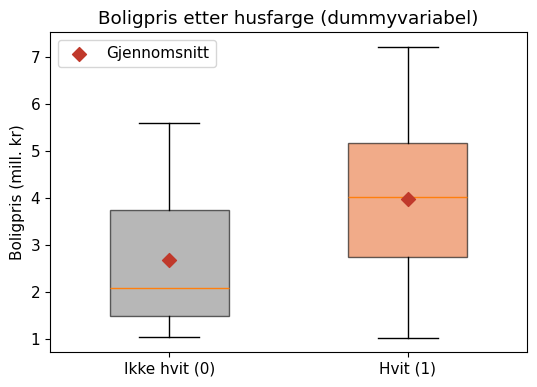

In [10]:
farge0 = df[df["Farge"] == 0]["Pris"] / 1e6
farge1 = df[df["Farge"] == 1]["Pris"] / 1e6
fig, ax = plt.subplots(figsize=(5.5, 4))
bp = ax.boxplot([farge0, farge1], tick_labels=["Ikke hvit (0)", "Hvit (1)"],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], [GRAY, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.scatter([1, 2], [farge0.mean(), farge1.mean()], color=RED, zorder=5, marker="D", s=50, label="Gjennomsnitt")
ax.set_ylabel("Boligpris (mill. kr)")
ax.set_title("Boligpris etter husfarge (dummyvariabel)")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Multippel regresjon

Med flere uavhengige variabler: $Y=b_0+b_1X_1+b_2X_2+\dots+b_nX_n$.

In [11]:
X_multi = sm.add_constant(df[["Areal", "Alder", "Sentrum", "Farge"]])
model_multi = sm.OLS(df["Pris"], X_multi).fit()
print(model_multi.params)
print(f"\nR2 = {model_multi.rsquared:.3f}  (mot {res.rvalue**2:.3f} med kun areal)")

const      2.612998e+06
Areal      1.289168e+04
Alder     -8.169335e+04
Sentrum   -1.242126e+05
Farge      4.785973e+05
dtype: float64

R2 = 0.836  (mot 0.307 med kun areal)


$$\hat{Pris}=2\,612\,998+12\,892\cdot Areal-81\,693\cdot Alder-124\,213\cdot Sentrum+478\,597\cdot Farge$$

Prisen **oker** med koeffisienten til Areal og Farge, og **synker** med koeffisienten til
Alder og Sentrum -- *alt annet likt*.

## 10. Justert $R^2$

$R^2$ vil (nesten) alltid oke nar vi legger til flere variabler, selv om de ikke bidrar reelt.
**Justert $R^2$** straffer for antall variabler og bor brukes ved sammenligning av modeller
med ulikt antall forklaringsvariabler.

In [12]:
modeller = {
    "Areal": ["Areal"],
    "Areal + Alder": ["Areal", "Alder"],
    "Areal + Alder + Sentrum": ["Areal", "Alder", "Sentrum"],
    "Areal + Alder + Sentrum + Farge": ["Areal", "Alder", "Sentrum", "Farge"],
}

rader = []
for navn, kolonner in modeller.items():
    Xm = sm.add_constant(df[kolonner])
    m = sm.OLS(df["Pris"], Xm).fit()
    rader.append({"Modell": navn, "R2": round(m.rsquared, 3), "Justert R2": round(m.rsquared_adj, 3)})

sammendrag = pd.DataFrame(rader)
sammendrag

,Modell,R2,Justert R2
0,Areal,0.307,0.300
1,Areal + Alder,0.787,0.783
2,Areal + Alder + Sentrum,0.819,0.813
3,Areal + Alder + Sentrum + Farge,0.836,0.829


Justert $R^2$ oker ved hvert steg -- alle fire variablene bidrar reelt til modellen.

## 11. ANOVA-test i lineaer regresjon

Nar vi kjorer en lineaer regresjon blir det samtidig utfort en ANOVA-test (variansanalyse)
som tester om modellen samlet sett forklarer signifikant variasjon:

$$H_0:\beta_1=\beta_2=\dots=\beta_k=0 \qquad H_A:\text{minst en }\beta_j\neq0$$

$$F=\frac{MSR}{MSE}=\frac{\text{Forklart varians per frihetsgrad}}{\text{Uforklart varians per frihetsgrad}}$$

In [13]:
X3 = sm.add_constant(df[["Areal", "Alder", "Sentrum"]])
model3 = sm.OLS(df["Pris"], X3).fit()

SSR = np.sum((model3.fittedvalues - df["Pris"].mean())**2)
SSE = np.sum(model3.resid**2)
SST = SSR + SSE
dfR, dfE = 3, len(df) - 3 - 1
MSR, MSE = SSR / dfR, SSE / dfE
F = MSR / MSE

print(f"SSR={SSR:.3e}, SSE={SSE:.3e}, SST={SST:.3e}")
print(f"dfR={dfR}, dfE={dfE}")
print(f"MSR={MSR:.3e}, MSE={MSE:.3e}")
print(f"F = {F:.3f}")
print(f"\nFra statsmodels direkte: F={model3.fvalue:.3f}, p={model3.f_pvalue:.3e}")

SSR=2.011e+14, SSE=4.457e+13, SST=2.457e+14
dfR=3, dfE=98
MSR=6.704e+13, MSE=4.548e+11
F = 147.421

Fra statsmodels direkte: F=147.421, p=3.395e-36


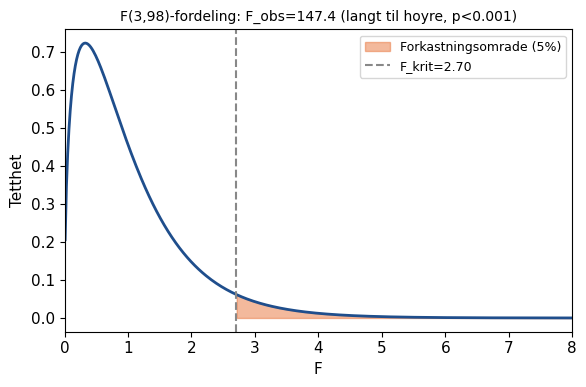

F=147.4 >> F_krit=2.70  ==>  forkaster H0: minst en koeffisient er forskjellig fra 0.


In [14]:
from scipy.stats import f as fdist
f_crit = fdist.ppf(0.95, dfR, dfE)
xs6 = np.linspace(0.01, 8, 400)
ys6 = fdist.pdf(xs6, dfR, dfE)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(xs6, ys6, color=BLUE, lw=2)
ax.fill_between(xs6[xs6 >= f_crit], ys6[xs6 >= f_crit], color=ORANGE, alpha=0.5, label="Forkastningsomrade (5%)")
ax.axvline(f_crit, color=GRAY, ls="--", label=f"F_krit={f_crit:.2f}")
ax.set_xlim(0, 8)
ax.set_xlabel("F"); ax.set_ylabel("Tetthet")
ax.set_title(f"F({dfR},{dfE})-fordeling: F_obs={F:.1f} (langt til hoyre, p<0.001)", fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"F={F:.1f} >> F_krit={f_crit:.2f}  ==>  forkaster H0: minst en koeffisient er forskjellig fra 0.")

## 12. Standardisert beta

De ustandardiserte koeffisientene kan ikke sammenlignes direkte -- de avhenger av
variablenes maleenheter. **Standardiserte** koeffisienter (beta-verdier) regnes ut ved a
standardisere alle variablene (trekke fra gjennomsnitt, dele pa standardavvik) for
regresjonen. De viser sammenhengen i *standardavviksenheter*.

In [15]:
kolonner = ["Areal", "Alder", "Sentrum"]
Xz = df[kolonner].apply(lambda c: (c - c.mean()) / c.std())
yz = (df["Pris"] - df["Pris"].mean()) / df["Pris"].std()
Xz = sm.add_constant(Xz)
model_z = sm.OLS(yz, Xz).fit()
betas = model_z.params.drop("const").sort_values()
print(betas)

Alder     -0.631454
Sentrum   -0.193597
Areal      0.414582
dtype: float64


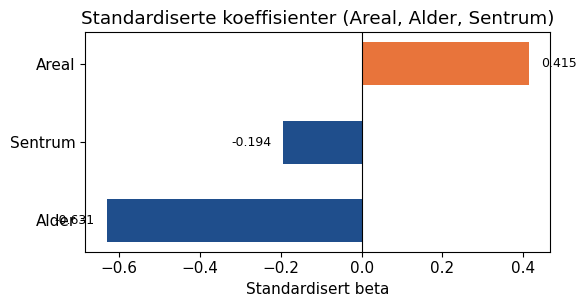


Storst betydning for boligprisen: Alder (|-0.631|)


In [16]:
fig, ax = plt.subplots(figsize=(6, 3.2))
colors = [ORANGE if b > 0 else BLUE for b in betas.values]
ax.barh(betas.index, betas.values, color=colors, height=0.55)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardisert beta")
ax.set_title("Standardiserte koeffisienter (Areal, Alder, Sentrum)")
for i, v in enumerate(betas.values):
    ax.text(v + (0.03 if v > 0 else -0.03), i, f"{v:.3f}", va="center",
            ha="left" if v > 0 else "right", fontsize=9)
plt.tight_layout()
plt.show()

storst = betas.abs().idxmax()
print(f"\nStorst betydning for boligprisen: {storst} (|{betas[storst]:.3f}|)")

**Alder** har storst betydning for boligprisen (storst absoluttverdi av standardisert
beta) -- storre effekt enn bade areal og avstand til sentrum, til tross for at den
ustandardiserte koeffisienten i kroner er mindre enn arealets.

## 13. Multikollinearitet

Oppstar nar to eller flere uavhengige variabler er sterkt korrelerte med hverandre. Males
med **VIF** (Variance Inflation Factor):

$$VIF_j=\frac{1}{1-R_j^2}$$

der $R_j^2$ er forklaringsgraden nar $X_j$ regresseres pa de andre uavhengige variablene.
Tommelfingerregel: $VIF>5$ (eller $10$) indikerer problematisk multikollinearitet.

In [17]:
X_vif = sm.add_constant(df[["Areal", "Alder", "Sentrum", "Farge"]])
vif_verdier = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns)
print(vif_verdier.round(3))

const      1.000
Areal      1.111
Alder      1.200
Sentrum    1.213
Farge      1.122
dtype: float64


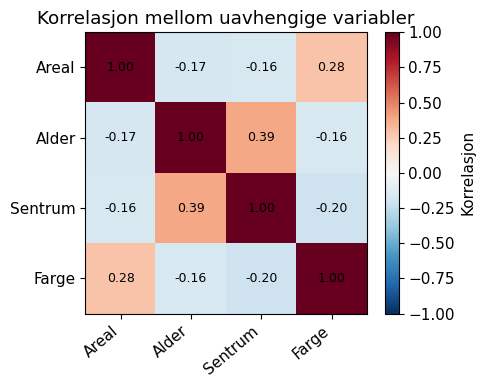


Alle VIF-verdier er nar 1 -- ingen problematisk multikollinearitet i denne modellen.


In [18]:
corr = df[["Areal", "Alder", "Sentrum", "Farge"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=40, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Korrelasjon")
ax.set_title("Korrelasjon mellom uavhengige variabler")
plt.tight_layout()
plt.show()

print("\nAlle VIF-verdier er nar 1 -- ingen problematisk multikollinearitet i denne modellen.")

## 14. Prediksjon

Modellen kan brukes til a predikere prisen for en ny bolig gitt areal, alder og avstand fra
sentrum.

**Advarsel:** ikke bruk modellen for boliger utenfor datasettets omfang (samme geografiske
omrade, samme intervall for areal/alder/avstand) -- ekstrapolering er upalitelig.

In [19]:
areal_ny, alder_ny, sentrum_ny = 200, 5, 6
pred = (model3.params["const"] + model3.params["Areal"] * areal_ny
        + model3.params["Alder"] * alder_ny + model3.params["Sentrum"] * sentrum_ny)
print(f"Modell: Pris = {model3.params['const']:.0f} + {model3.params['Areal']:.0f}*Areal "
      f"+ {model3.params['Alder']:.0f}*Alder + {model3.params['Sentrum']:.0f}*Sentrum")
print(f"\nPrediksjon for {areal_ny} kvm, {alder_ny} ar, {sentrum_ny} km fra sentrum:")
print(f"Pris = {pred:,.0f} kr".replace(",", " "))

Modell: Pris = 2796368 + 14070*Areal + -82827*Alder + -138114*Sentrum

Prediksjon for 200 kvm, 5 ar, 6 km fra sentrum:
Pris = 4 367 547 kr


## Oppsummering

| Begrep | Beskrivelse | Python |
|---|---|---|
| Kurvetilpasning | Finne en funksjon som beskriver sammenhengen i dataene | `np.polyfit` |
| Avhengig/uavhengig variabel | Det vi forklarer (y) vs. det vi forklarer med (x) | -- |
| Minste kvadraters metode | Finner regresjonslinjen som minimerer summen av kvadrerte feilledd | `stats.linregress` |
| Regresjonslinje, stigningstall, konstantledd | $\hat y=\hat\alpha+\hat\beta x$ | `res.intercept`, `res.slope` |
| $R^2$ | Andel av variansen i y som forklares av modellen | `res.rvalue**2` |
| Beta-koeffisient | Ustandardisert koeffisient til hver forklaringsvariabel | `model.params` |
| Indikator-/dummyvariabel | Kategorisk variabel (0/1) brukt som forklaringsvariabel | -- |
| Multippel regresjon | Flere forklaringsvariabler samtidig | `sm.OLS` |
| Justert $R^2$ | Straffer for antall variabler | `model.rsquared_adj` |
| ANOVA/F-test | Tester om modellen samlet forklarer signifikant variasjon | `model.fvalue`, `model.f_pvalue` |
| Standardisert beta | Sammenlignbar effektstorrelse pa tvers av variabler | standardiser for regresjon |
| Multikollinearitet (VIF) | Sjekker om prediktorene er for sterkt korrelerte | `variance_inflation_factor` |
| Prediksjon | Bruke modellen til a anslå y for nye x-verdier | -- |

Alle beregninger er gjort med `numpy`, `scipy.stats`, `statsmodels` og `pyreadstat` i Python.